<a href="https://colab.research.google.com/github/pjastr-uwm/fakultet_io_2026/blob/main/lab06/lab06C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zaawansowana EDA na tekście ustawy „Prawo komunikacji elektronicznej"



---
## 0. Pobranie pliku PDF i instalacja bibliotek

Poniżej dwie opcje uzyskania pliku PDF w środowisku Google Colab:
- **Opcja A** – pobranie pliku z Google Drive (wymaga wcześniejszego wgrania pliku na Dysk Google)
- **Opcja B** – ręczny upload pliku z dysku lokalnego

In [ ]:
# Instalacja wymaganych bibliotek
!pip install pdfplumber -q

In [ ]:
# === OPCJA A: Montowanie Google Drive ===
# Odkomentuj poniższe linie, jeśli plik D20241221Lj.pdf jest na Twoim Dysku Google
# (np. w folderze "Colab Notebooks" lub w głównym katalogu "My Drive")

from google.colab import drive
drive.mount('/content/drive')

# Dostosuj ścieżkę do lokalizacji pliku na Twoim Dysku Google:
PDF_PATH = "/content/drive/MyDrive/D20241221Lj.pdf"

# === OPCJA B: Upload pliku z komputera ===
# Odkomentuj poniższe linie, aby wgrać plik ręcznie:

# from google.colab import files
# uploaded = files.upload()  # pojawi się okno dialogowe wyboru pliku
# PDF_PATH = "D20241221Lj.pdf"

# === Domyślna ścieżka (jeśli plik jest już w katalogu roboczym) ===
# PDF_PATH = "D20241221Lj.pdf"
print(f"Ścieżka do pliku: {PDF_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ścieżka do pliku: /content/drive/MyDrive/D20241221Lj.pdf


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber
import re
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
print("Wszystko gotowe!")

Wszystko gotowe!


---
## 1. Ekstrakcja tekstu z PDF i podział na segmenty

In [ ]:
# Ekstrakcja pełnego tekstu z PDF
full_text = ""
with pdfplumber.open(PDF_PATH) as pdf:
    print(f"Liczba stron: {len(pdf.pages)}")
    for page in pdf.pages:
        page_text = page.extract_text()
        if page_text:
            full_text += page_text + "\n"

print(f"Łączna liczba znaków: {len(full_text):,}")
print(f"Łączna liczba słów: {len(full_text.split()):,}")
print(f"\nPierwsze 500 znaków:\n{full_text[:500]}")

Liczba stron: 331
Łączna liczba znaków: 737,288
Łączna liczba słów: 99,658

Pierwsze 500 znaków:
©Kancelaria Sejmu s. 1/331
Dz. U. 2024 poz. 1221
USTAWA
Opracowano na
podstawie: Dz. U.
z dnia 12 lipca 2024 r.
z 2024 r. poz.
1221, z 2025 r.
Prawo komunikacji elektronicznej1) poz. 637, 820, z
2026 r. poz. 252.
DZIAŁ I
Przepisy ogólne
Rozdział 1
Zakres ustawy
Art. 1. 1. Ustawa określa:
1) Niniejsza ustawa:
1) w zakresie swojej regulacji wdraża:
a) dyrektywę 2002/58/WE Parlamentu Europejskiego i Rady z dnia 12 lipca 2002 r. dotyczącą
przetwarzania danych osobowych i ochrony prywatności w sektor


### 1.1 Podział na artykuły

In [ ]:
# Podział tekstu na artykuły (Art. 1, Art. 2, ...)
# Szukamy wzorca "Art. N." na początku linii lub po znaku nowej linii
art_pattern = re.compile(r'(?:^|\n)(Art\.\s*\d+[a-z]?\.)', re.MULTILINE)

# Znajdź pozycje wszystkich artykułów
art_matches = list(art_pattern.finditer(full_text))
print(f"Znaleziono {len(art_matches)} wystąpień nagłówków artykułów")

# Wyodrębnij tekst każdego artykułu (od nagłówka do kolejnego nagłówka)
articles = []
for i, match in enumerate(art_matches):
    start = match.start()
    end = art_matches[i + 1].start() if i + 1 < len(art_matches) else len(full_text)
    art_name = match.group(1).strip()
    art_text = full_text[start:end].strip()
    articles.append({"article": art_name, "text": art_text})

df_articles = pd.DataFrame(articles)
# Deduplikacja -- bierzemy pierwsze wystąpienie każdego artykułu
df_articles = df_articles.drop_duplicates(subset="article", keep="first").reset_index(drop=True)
print(f"Unikalne artykuły: {len(df_articles)}")
df_articles.head(10)

Znaleziono 450 wystąpień nagłówków artykułów
Unikalne artykuły: 450


,article,text
0,Art. 1.,Art. 1. 1. Ustawa określa:\n1) Niniejsza ustaw...
1,Art. 2.,Art. 2. Określenia użyte w ustawie oznaczają:\...
2,Art. 3.,Art. 3. 1. Dla zwiększenia efektywności teleko...
3,Art. 4.,Art. 4. 1. Prezes Urzędu Komunikacji Elektroni...
4,Art. 5.,Art. 5. 1. Działalność telekomunikacyjna będąc...
5,Art. 6.,Art. 6. 1. Wpis do rejestru PT dokonywany jest...
6,Art. 7.,Art. 7. 1. Wpis do rejestru JST dokonywany jes...
7,Art. 8.,Art. 8. 1. Prezes UKE dokonuje wpisu do rejest...
8,Art. 9.,Art. 9. Rejestr PT obejmuje:\n1) kolejny numer...
9,Art. 10.,Art. 10. Rejestr JST obejmuje:\n1) kolejny num...


### 1.2 Podział na działy

In [ ]:
# Podział na działy (DZIAŁ I, DZIAŁ II, ...)
dzial_pattern = re.compile(r'(?:^|\n)(DZIAŁ\s+[IVXLCDM]+)', re.MULTILINE)
dzial_matches = list(dzial_pattern.finditer(full_text))
print(f"Znaleziono {len(dzial_matches)} działów")

sections = []
for i, match in enumerate(dzial_matches):
    start = match.start()
    end = dzial_matches[i + 1].start() if i + 1 < len(dzial_matches) else len(full_text)
    sec_name = match.group(1).strip()
    sec_text = full_text[start:end].strip()
    sections.append({"dzial": sec_name, "text": sec_text})

df_sections = pd.DataFrame(sections)
print(f"\nDziały ustawy:")
for _, row in df_sections.iterrows():
    print(f"  {row['dzial']:15s} – {len(row['text']):>6,} znaków, {len(row['text'].split()):>5,} słów")

Znaleziono 10 działów

Działy ustawy:
  DZIAŁ I         – 162,768 znaków, 22,031 słów
  DZIAŁ II        – 148,737 znaków, 19,612 słów
  DZIAŁ III       – 33,700 znaków, 4,867 słów
  DZIAŁ IV        – 80,857 znaków, 10,679 słów
  DZIAŁ V         –  6,558 znaków,   916 słów
  DZIAŁ VI        – 19,566 znaków, 2,663 słów
  DZIAŁ VII       – 203,532 znaków, 27,398 słów
  DZIAŁ VIII      – 57,820 znaków, 7,921 słów
  DZIAŁ IX        – 23,317 znaków, 3,497 słów
  DZIAŁ X         –    210 znaków,    34 słów


### 1.3 Podział na zdania

In [ ]:
# Podział tekstu na zdania (uproszczony – po kropce, wykrzykniku, znaku zapytania)
# Pomijamy skróty prawnicze (Art., Dz., nr, poz., ust., itd.)
sentence_pattern = re.compile(
    r'(?<![A-Z])(?<!Art)(?<!art)(?<!Dz)(?<!poz)(?<!ust)(?<!nr)(?<!str)(?<!pkt)(?<!lit)(?<!zd)(?<!zm)'
    r'(?<!\d)\.'
    r'\s+'
)

# Najpierw wyczyśćmy tekst z nagłówków stron (©Kancelaria Sejmu, numery stron)
clean_text = re.sub(r'©Kancelaria Sejmu\n\ns\. \d+/\d+', '', full_text)
clean_text = re.sub(r'\d{4}-\d{2}-\d{2}', '', clean_text)

raw_sentences = sentence_pattern.split(clean_text)
sentences = [s.strip() for s in raw_sentences if len(s.strip()) > 20]

df_sentences = pd.DataFrame({"sentence": sentences})
print(f"Wyodrębniono {len(df_sentences)} zdań/fragmentów")
print(f"\nPrzykładowe zdania:")
for i in range(min(5, len(df_sentences))):
    print(f"  [{i}] {df_sentences.iloc[i]['sentence'][:120]}...")

Wyodrębniono 2207 zdań/fragmentów

Przykładowe zdania:
  [0] 1/331
Dz. U. 2024 poz. 1221
USTAWA
Opracowano na
podstawie: Dz. U.
z dnia 12 lipca 2024 r...
  [1] Prawo komunikacji elektronicznej1) poz. 637, 820, z
2026 r...
  [2] poz. 252.
DZIAŁ I
Przepisy ogólne
Rozdział 1
Zakres ustawy
Art. 1. 1. Ustawa określa:
1) Niniejsza ustawa:
1) w zakresie...
  [3] dotyczącą
przetwarzania danych osobowych i ochrony prywatności w sektorze łączności elektronicznej
(dyrektywa o prywatno...
  [4] WE L 201 z 31.07.2002,
str. 37, z późn...


---
## 2. Podstawowe statystyki tekstowe (Krok 2)

Obliczamy dla trzech perspektyw: artykuły, działy, zdania.

In [ ]:
# Dodajemy kolumny ze statystykami
for df, col in [(df_articles, "text"), (df_sections, "text"), (df_sentences, "sentence")]:
    df["num_chars"] = df[col].str.len()
    df["num_words"] = df[col].str.split().str.len()

# Tabela porównawcza
summary = pd.DataFrame({
    "Segmentacja": ["Artykuły", "Działy", "Zdania"],
    "Liczba segmentów": [len(df_articles), len(df_sections), len(df_sentences)],
    "Śr. długość (znaki)": [
        df_articles["num_chars"].mean(),
        df_sections["num_chars"].mean(),
        df_sentences["num_chars"].mean()
    ],
    "Mediana (znaki)": [
        df_articles["num_chars"].median(),
        df_sections["num_chars"].median(),
        df_sentences["num_chars"].median()
    ],
    "Śr. liczba słów": [
        df_articles["num_words"].mean(),
        df_sections["num_words"].mean(),
        df_sentences["num_words"].mean()
    ],
    "Mediana (słowa)": [
        df_articles["num_words"].median(),
        df_sections["num_words"].median(),
        df_sentences["num_words"].median()
    ],
})
summary = summary.round(1)
print("Tabela porównawcza statystyk tekstowych:")
summary

Tabela porównawcza statystyk tekstowych:


,Segmentacja,Liczba segmentów,Śr. długość (znaki),Mediana (znaki),Śr. liczba słów,Mediana (słowa)
0,Artykuły,450,1636.8,1046.5,221.4,140.0
1,Działy,10,73706.5,45760.0,9961.8,6394.0
2,Zdania,2207,329.4,233.0,44.8,32.0


---
## 3. Porównawcze histogramy długości tekstu (Krok 3)

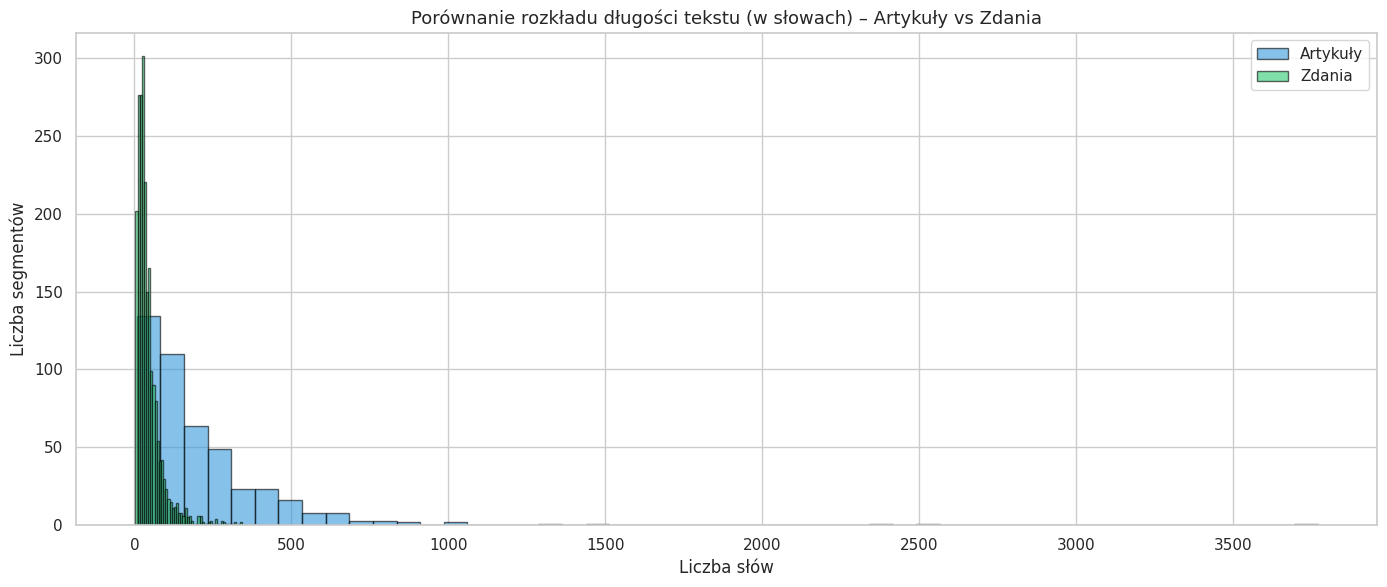

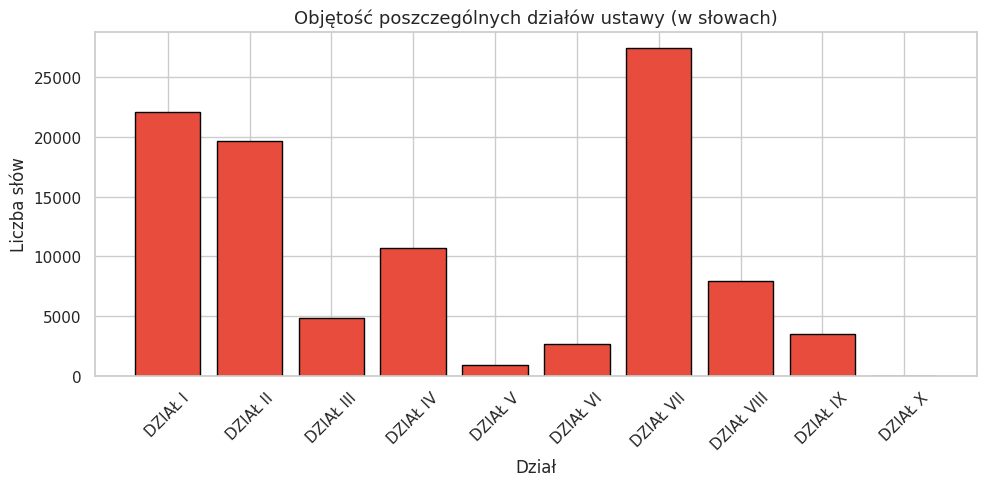

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(df_articles["num_words"], bins=50, alpha=0.6, label="Artykuły", color="#3498db", edgecolor="black")
ax.hist(df_sentences["num_words"], bins=50, alpha=0.6, label="Zdania", color="#2ecc71", edgecolor="black")

ax.set_title("Porównanie rozkładu długości tekstu (w słowach) – Artykuły vs Zdania", fontsize=13)
ax.set_xlabel("Liczba słów")
ax.set_ylabel("Liczba segmentów")
ax.legend()

plt.tight_layout()
plt.show()

# Osobny histogram dla działów (inna skala)
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.bar(df_sections["dzial"], df_sections["num_words"], color="#e74c3c", edgecolor="black")
ax2.set_title("Objętość poszczególnych działów ustawy (w słowach)", fontsize=13)
ax2.set_xlabel("Dział")
ax2.set_ylabel("Liczba słów")
ax2.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---
## 4. Analiza struktury działów (Krok 4)

Badamy rozkład artykułów w poszczególnych działach i wyświetlamy przykładowe fragmenty.

In [ ]:
# Przypisz każdy artykuł do działu
def assign_dzial(art_text):
    """Znajdź, w którym dziale mieści się artykuł na podstawie pozycji w tekście."""
    art_pos = full_text.find(art_text[:80])
    best_dzial = "DZIAŁ I"
    for _, row in df_sections.iterrows():
        sec_pos = full_text.find(row["text"][:80])
        if sec_pos <= art_pos:
            best_dzial = row["dzial"]
    return best_dzial

df_articles["dzial"] = df_articles["text"].apply(assign_dzial)

print("Rozkład artykułów w działach:")
print(df_articles["dzial"].value_counts().sort_index())
print()

# Przykład: po 1 artykule z każdego działu
print("Przykładowe artykuły z każdego działu:")
for dzial in df_sections["dzial"]:
    subset = df_articles[df_articles["dzial"] == dzial]
    if len(subset) > 0:
        ex = subset.iloc[0]
        print(f"\n  {dzial} → {ex['article']}")
        print(f"    {ex['text'][:150]}...")

Rozkład artykułów w działach:
dzial
DZIAŁ I        60
DZIAŁ II      107
DZIAŁ III      30
DZIAŁ IV       66
DZIAŁ IX        6
DZIAŁ V         8
DZIAŁ VI       10
DZIAŁ VII     129
DZIAŁ VIII     33
DZIAŁ X         1
Name: count, dtype: int64

Przykładowe artykuły z każdego działu:

  DZIAŁ I → Art. 1.
    Art. 1. 1. Ustawa określa:
1) Niniejsza ustawa:
1) w zakresie swojej regulacji wdraża:
a) dyrektywę 2002/58/WE Parlamentu Europejskiego i Rady z dnia ...

  DZIAŁ II → Art. 61.
    Art. 61. Ilekroć w niniejszym rozdziale jest mowa o grupie kapitałowej, rozumie
się przez to grupę kapitałową w rozumieniu art. 4 pkt 14 ustawy z dnia...

  DZIAŁ III → Art. 168.
    Art. 168. 1. Dostęp telekomunikacyjny świadczony jest na podstawie umowy
zawieranej w formie dokumentowej pod rygorem nieważności, zwanej dalej „umową...

  DZIAŁ IV → Art. 198.
    Art. 198. 1. Prezes UKE przeprowadza analizę rynku w zakresie produktów lub
usług komunikacji elektronicznej.
2. Prezes UKE, nie później niż w term

---
## 5. Type-Token Ratio (TTR) – bogactwo słownictwa (Krok 5)

In [ ]:
# Tokenizacja
def tokenize_simple(text):
    text = text.lower()
    tokens = re.findall(r'\b[a-ząćęłńóśźż]+\b', text)
    return tokens

# Polskie stopwords
polish_stopwords = {
    "i", "w", "na", "z", "do", "nie", "się", "to", "jest", "że",
    "o", "jak", "ale", "co", "tak", "za", "po", "od", "już", "a",
    "przez", "by", "tym", "ze", "tego", "ten", "ta", "te", "bardzo",
    "też", "tylko", "czy", "był", "była", "było", "być", "są",
    "ma", "ich", "dla", "mnie", "mi", "ja", "sobie", "go",
    "przy", "u", "no", "jeszcze", "tu", "tam", "kiedy", "gdy",
    "wszystko", "może", "więc", "który", "która", "które", "których",
    "którzy", "mam", "będzie", "lub", "oraz", "art", "ust",
    "pkt", "lit", "nr", "poz", "str", "dz"
}

results_ttr = {}
for name, df, col in [
    ("Artykuły", df_articles, "text"),
    ("Działy", df_sections, "text"),
    ("Zdania", df_sentences, "sentence")
]:
    all_tokens = []
    for text in df[col]:
        tokens = tokenize_simple(text)
        filtered = [t for t in tokens if t not in polish_stopwords and len(t) > 2]
        all_tokens.extend(filtered)

    unique = len(set(all_tokens))
    total = len(all_tokens)
    ttr = unique / total if total > 0 else 0
    results_ttr[name] = {"unique": unique, "total": total, "TTR": ttr}

df_ttr = pd.DataFrame(results_ttr).T
df_ttr["TTR"] = df_ttr["TTR"].round(4)
print("Type-Token Ratio (TTR = unikalne słowa / wszystkie słowa):")
print(f"Im wyższy TTR, tym bogatsze słownictwo.\n")
df_ttr

Type-Token Ratio (TTR = unikalne słowa / wszystkie słowa):
Im wyższy TTR, tym bogatsze słownictwo.



,unique,total,TTR
Artykuły,7399.0,62006.0,0.1193
Działy,7399.0,62012.0,0.1193
Zdania,7399.0,61821.0,0.1197


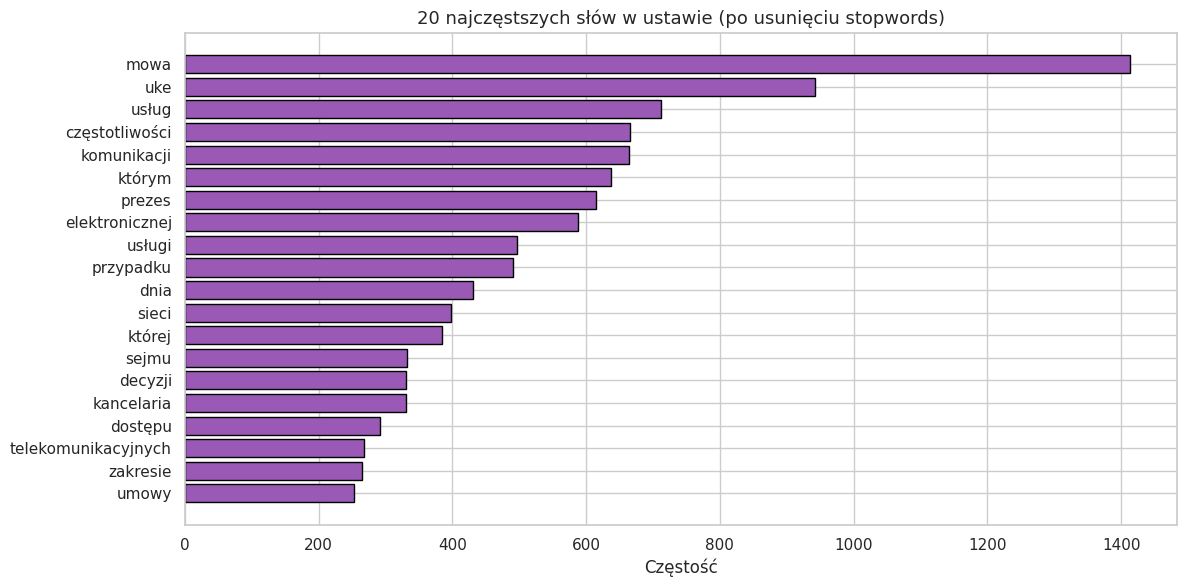

In [ ]:
# Top 20 najczęstszych słów w ustawie (bez stopwords)
all_words_law = []
for text in df_articles["text"]:
    tokens = tokenize_simple(text)
    filtered = [t for t in tokens if t not in polish_stopwords and len(t) > 2]
    all_words_law.extend(filtered)

top_20_law = Counter(all_words_law).most_common(20)

fig, ax = plt.subplots(figsize=(12, 6))
words, counts = zip(*top_20_law)
ax.barh(range(len(words)), counts, color="#9b59b6", edgecolor="black")
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel("Częstość")
ax.set_title("20 najczęstszych słów w ustawie (po usunięciu stopwords)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Dashboard podsumowujący (Krok 6)

/tmp/ipykernel_8875/1981978387.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_articles, x="dzial", y="num_words", ax=axes[1, 1],


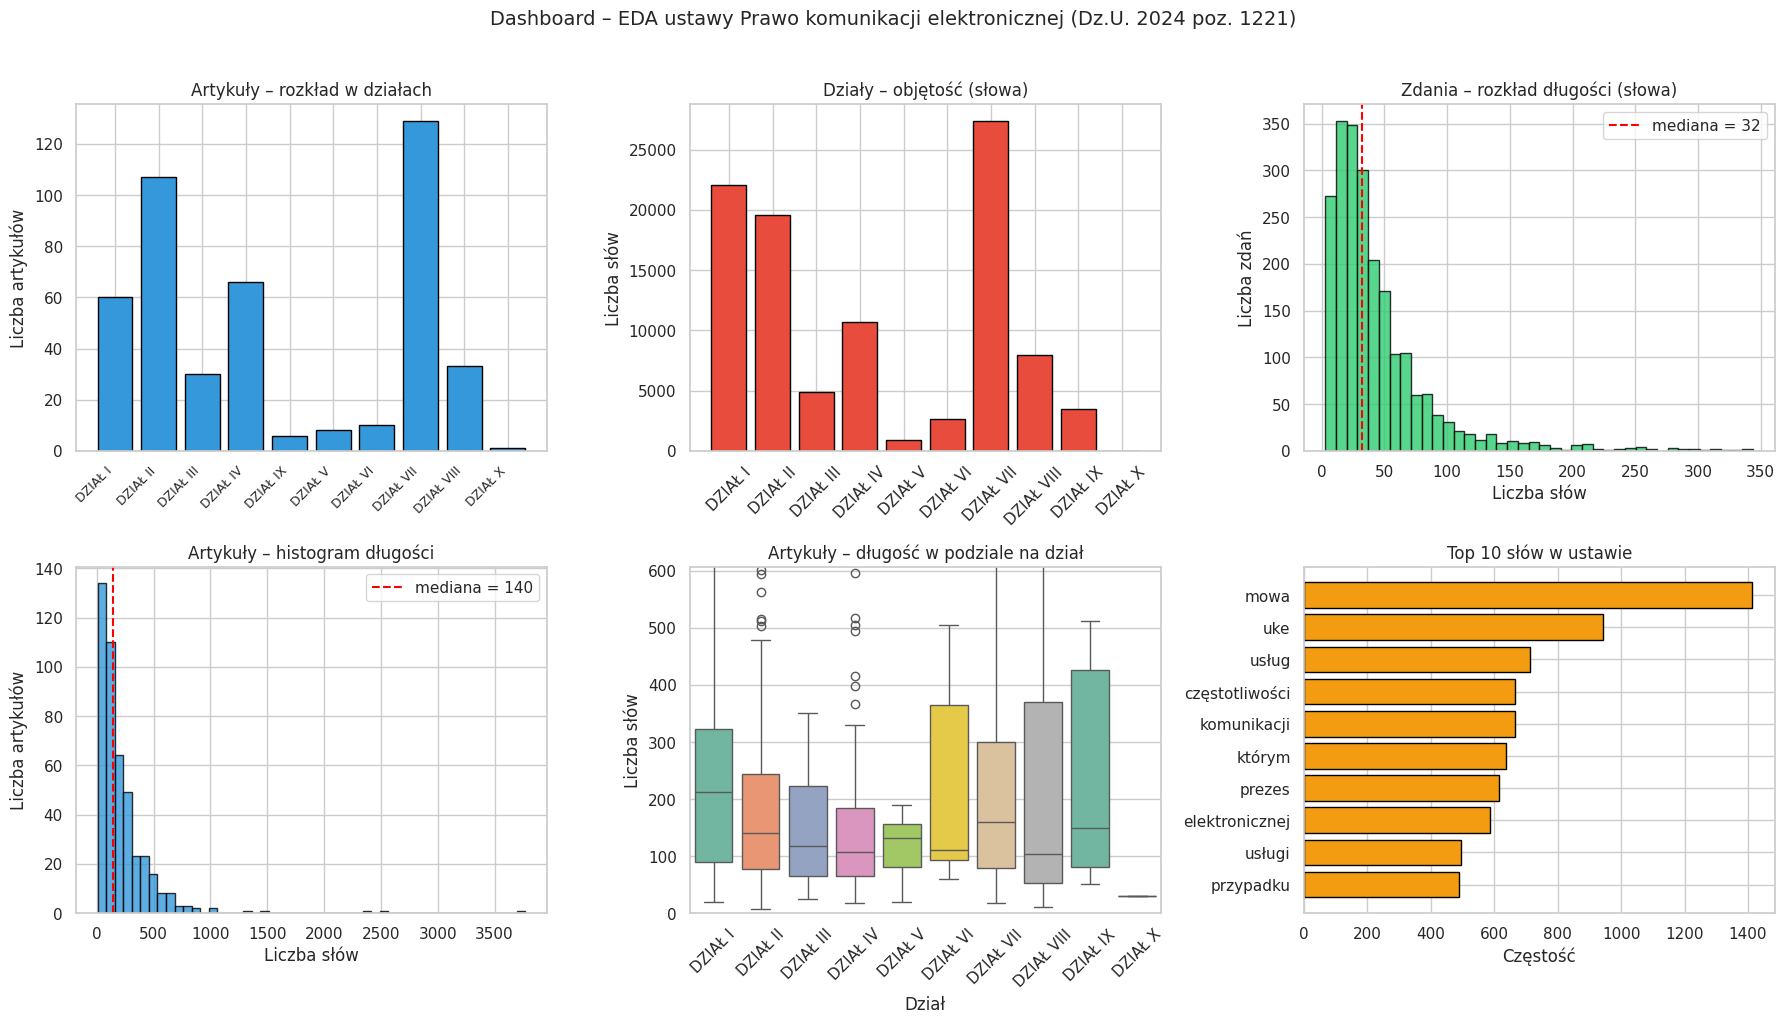

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Górny rząd: rozkład/struktura dla każdej segmentacji ---

# Panel 1: Rozkład artykułów w działach
art_per_dzial = df_articles["dzial"].value_counts().sort_index()
axes[0, 0].bar(range(len(art_per_dzial)), art_per_dzial.values, color="#3498db", edgecolor="black")
axes[0, 0].set_xticks(range(len(art_per_dzial)))
axes[0, 0].set_xticklabels(art_per_dzial.index, rotation=45, ha="right", fontsize=9)
axes[0, 0].set_title("Artykuły – rozkład w działach", fontsize=12)
axes[0, 0].set_ylabel("Liczba artykułów")

# Panel 2: Objętość działów (słowa)
axes[0, 1].bar(df_sections["dzial"], df_sections["num_words"], color="#e74c3c", edgecolor="black")
axes[0, 1].set_title("Działy – objętość (słowa)", fontsize=12)
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].set_ylabel("Liczba słów")

# Panel 3: Rozkład długości zdań (bar/hist)
axes[0, 2].hist(df_sentences["num_words"], bins=40, color="#2ecc71", edgecolor="black", alpha=0.8)
axes[0, 2].axvline(df_sentences["num_words"].median(), color="red", linestyle="--",
                    label=f'mediana = {df_sentences["num_words"].median():.0f}')
axes[0, 2].set_title("Zdania – rozkład długości (słowa)", fontsize=12)
axes[0, 2].set_xlabel("Liczba słów")
axes[0, 2].set_ylabel("Liczba zdań")
axes[0, 2].legend()

# --- Dolny rząd: histogramy długości tekstu ---

# Panel 4: Histogram artykułów
axes[1, 0].hist(df_articles["num_words"], bins=50, color="#3498db", edgecolor="black", alpha=0.8)
axes[1, 0].axvline(df_articles["num_words"].median(), color="red", linestyle="--",
                    label=f'mediana = {df_articles["num_words"].median():.0f}')
axes[1, 0].set_title("Artykuły – histogram długości", fontsize=12)
axes[1, 0].set_xlabel("Liczba słów")
axes[1, 0].set_ylabel("Liczba artykułów")
axes[1, 0].legend()

# Panel 5: Boxplot długości artykułów per dział
dzial_order = df_sections["dzial"].tolist()
sns.boxplot(data=df_articles, x="dzial", y="num_words", ax=axes[1, 1],
            order=dzial_order, palette="Set2")
axes[1, 1].set_title("Artykuły – długość w podziale na dział", fontsize=12)
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].set_xlabel("Dział")
axes[1, 1].set_ylabel("Liczba słów")
axes[1, 1].set_ylim(0, df_articles["num_words"].quantile(0.95))

# Panel 6: Top 10 słów (poziomy barplot)
top_10_dash = Counter(all_words_law).most_common(10)
w10, c10 = zip(*top_10_dash)
axes[1, 2].barh(range(len(w10)), c10, color="#f39c12", edgecolor="black")
axes[1, 2].set_yticks(range(len(w10)))
axes[1, 2].set_yticklabels(w10)
axes[1, 2].invert_yaxis()
axes[1, 2].set_title("Top 10 słów w ustawie", fontsize=12)
axes[1, 2].set_xlabel("Częstość")

plt.suptitle("Dashboard – EDA ustawy Prawo komunikacji elektronicznej (Dz.U. 2024 poz. 1221)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
### Interpretacja

Dashboard podsumowuje kluczowe cechy tekstu ustawy:

- **Górny rząd** pokazuje strukturę dokumentu: rozkład artykułów między działami, objętość poszczególnych działów oraz typową długość zdania.
- **Dolny rząd** zawiera szczegółowe analizy: histogram długości artykułów, porównanie rozmiarów artykułów w działach (boxplot) oraz najczęstsze słowa, które odzwierciedlają tematykę ustawy (telekomunikacja, sieci, usługi).
- **TTR** (Type-Token Ratio) pozwala ocenić bogactwo słownictwa – teksty prawne zwykle mają niższy TTR ze względu na powtarzalność terminologii.

## Ćwiczenie dodatkowe – samodzielna analiza EDA na wybranym dokumencie PDF

### Polecenie

Wybierz **samodzielnie** dowolny dokument PDF w języku polskim o objętości **co najmniej 100 stron**. Może to być np. inna ustawa, kodeks, raport NIK, raport roczny spółki giełdowej itp. Dobre źródła to m.in.:

- **ISAP** (isap.sejm.gov.pl) – teksty jednolite ustaw
- **NIK** (nik.gov.pl) – raporty pokontrolne

### Kroki do wykonania

1. **Wgraj plik PDF** do środowiska Google Colab (przez Google Drive lub upload) i wyodrębnij pełny tekst za pomocą `pdfplumber`.

2. **Zaproponuj trzy sensowne segmentacje** tekstu dostosowane do struktury Twojego dokumentu. Przykładowo: dla kodeksu mogą to być artykuły / tytuły / księgi, dla raportu NIK – rozdziały / akapity / zalecenia, dla pracy naukowej – rozdziały / podrozdziały / zdania.

3. **Oblicz tabelę porównawczą statystyk** (liczba segmentów, średnia/mediana długości w znakach i słowach) dla każdej z trzech segmentacji – analogicznie do kroku 2 z notatnika.

4. **Narysuj porównawcze histogramy** długości tekstu dla co najmniej dwóch segmentacji na jednym wykresie oraz wykres słupkowy objętości największych jednostek strukturalnych (odpowiednik działów).

5. **Oblicz TTR** (Type-Token Ratio) dla każdej segmentacji i porównaj wyniki z wartościami uzyskanymi dla ustawy Prawo komunikacji elektronicznej. Który dokument ma bogatsze słownictwo i dlaczego?

6. **Przygotuj dashboard** `plt.subplots(2, 3)` z sześcioma panelami podsumowującymi analizę Twojego dokumentu.

7. **Napisz krótką interpretację** (5–10 zdań) porównującą Twój dokument z ustawą PKE pod kątem: przeciętnej długości jednostek tekstu, bogactwa słownictwa (TTR), rozkładu objętości między głównymi częściami dokumentu oraz dominujących słów kluczowych.